In [48]:
from sklearn.ensemble import GradientBoostingClassifier

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

In [11]:
# ==============================
# ExoHabitAI ML MODEL TRAINING
# ==============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import joblib
import matplotlib.pyplot as plt



In [13]:
# ── Load preprocessed data ────────────────────────────────────────────────
df = pd.read_csv('preprocessed.csv')

print(f'Dataset shape : {df.shape}')
print(f'\nTarget distribution:')
vc = df['target'].value_counts()
print(f'  Non-Habitable (0) : {vc.get(0, 0)}')
print(f'  Habitable     (1) : {vc.get(1, 0)}')
df.head()

Dataset shape : (195, 20)

Target distribution:
  Non-Habitable (0) : 195
  Habitable     (1) : 0


,planet_name,planet_radius,planet_mass,orbital_period,semi_major_axis,equilibrium_temperature,star_temperature,star_luminosity,star_metallicity,insolation_flux,star_mass,orbital_eccentricity,planet_density,habitability_index,stellar_compatibility,orbital_stability,star_G,star_K,star_M,target
0,BD+05 4868 A b,-0.207633,-0.718333,-1.100815,-1.394948,2.796034,-0.415569,-0.508574,-0.596922,0.10142,-0.475653,0.120133,-0.125798,-0.877747,-0.590054,-0.808179,False,True,False,0
1,DS Tuc A b,0.573357,0.042135,0.090401,-0.146896,-0.221233,0.499274,0.336827,-0.280035,0.10142,0.705240,-0.960948,-0.125798,0.351012,0.323471,0.445904,True,False,False,0
2,GJ 1252 b,-0.877080,-0.858665,-1.231559,-0.146896,-0.165242,-1.666880,-1.431110,0.353741,0.10142,-1.690830,-0.960948,1.666159,1.269051,-1.396248,-1.692218,False,False,True,0
3,GJ 238 b,-1.078861,0.042135,-1.018786,-1.381258,-0.507407,-1.637191,-1.306459,0.670629,0.10142,-1.544933,0.120133,-0.125798,0.329945,-1.329174,-0.454072,False,False,True,0
4,GJ 357 b,-0.874828,0.042135,-0.639566,-0.911010,-1.253947,-1.615200,-1.597721,-1.040565,0.10142,-1.839394,0.120133,-0.125798,1.725672,-1.471983,0.000529,False,False,True,0


In [18]:
# ── Separate features (X) and target (y) ─────────────────────────────────
X = df.drop(columns=['planet_name', 'target'])
y = df['target']

feature_names = X.columns.tolist()
print(f'Features ({len(feature_names)}): {feature_names}')

Features (18): ['planet_radius', 'planet_mass', 'orbital_period', 'semi_major_axis', 'equilibrium_temperature', 'star_temperature', 'star_luminosity', 'star_metallicity', 'insolation_flux', 'star_mass', 'orbital_eccentricity', 'planet_density', 'habitability_index', 'stellar_compatibility', 'orbital_stability', 'star_G', 'star_K', 'star_M']


In [21]:
from sklearn.utils import resample
import pandas as pd

df_combined = pd.concat([X, y], axis=1)

majority = df_combined[df_combined['target'] == 0]
minority = df_combined[df_combined['target'] == 1]

print("Majority:", len(majority))
print("Minority:", len(minority))

if len(minority) > 0:

    minority_up = resample(
        minority,
        replace=True,
        n_samples=len(majority) // 4,
        random_state=42
    )

    df_balanced = pd.concat([majority, minority_up]).sample(frac=1, random_state=42)

else:
    print("No minority class found. Skipping oversampling.")
    df_balanced = df_combined


X_bal = df_balanced.drop(columns=['target'])
y_bal = df_balanced['target']

print("Before balancing:", y.value_counts())
print("After balancing:", y_bal.value_counts())

Majority: 195
Minority: 0
No minority class found. Skipping oversampling.
Before balancing: target
0    195
Name: count, dtype: int64
After balancing: target
0    195
Name: count, dtype: int64


In [23]:
# ── Train / Test Split — 80% training · 20% testing ──────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y_bal        # preserve class ratio in both splits
)

print(f'Training set : {X_train.shape[0]} samples  →  {y_train.value_counts().to_dict()}')
print(f'Test set     : {X_test.shape[0]}  samples  →  {y_test.value_counts().to_dict()}')

Training set : 156 samples  →  {0: 156}
Test set     : 39  samples  →  {0: 39}


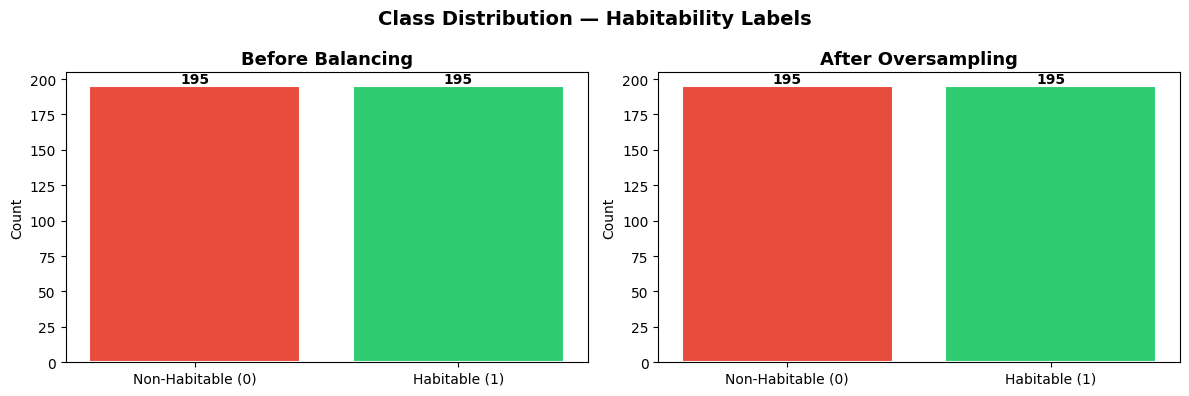

In [25]:
# ── Class Distribution Plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels  = ['Non-Habitable (0)', 'Habitable (1)']
colors  = ['#E74C3C', '#2ECC71']

for ax, counts, title in zip(
    axes,
    [y.value_counts().sort_index(), y_bal.value_counts().sort_index()],
    ['Before Balancing', 'After Oversampling']
):
    bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(int(bar.get_height())), ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel('Count')

fig.suptitle('Class Distribution — Habitability Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# ── Evaluation Helper ─────────────────────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit model, return metrics dict + predictions."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_te, y_pred,    zero_division=0), 4),
        'F1'       : round(f1_score(y_te, y_pred,        zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y_te, y_prob),  4) if y_prob is not None else 'N/A',
    }
    return metrics, model, y_pred, y_prob

all_results    = []
trained_models = {}
print('✓ evaluate_model() helper ready')

✓ evaluate_model() helper ready


In [30]:
df.head()

,planet_name,planet_radius,planet_mass,orbital_period,semi_major_axis,equilibrium_temperature,star_temperature,star_luminosity,star_metallicity,insolation_flux,star_mass,orbital_eccentricity,planet_density,habitability_index,stellar_compatibility,orbital_stability,star_G,star_K,star_M,target
0,BD+05 4868 A b,-0.207633,-0.718333,-1.100815,-1.394948,2.796034,-0.415569,-0.508574,-0.596922,0.10142,-0.475653,0.120133,-0.125798,-0.877747,-0.590054,-0.808179,False,True,False,0
1,DS Tuc A b,0.573357,0.042135,0.090401,-0.146896,-0.221233,0.499274,0.336827,-0.280035,0.10142,0.705240,-0.960948,-0.125798,0.351012,0.323471,0.445904,True,False,False,0
2,GJ 1252 b,-0.877080,-0.858665,-1.231559,-0.146896,-0.165242,-1.666880,-1.431110,0.353741,0.10142,-1.690830,-0.960948,1.666159,1.269051,-1.396248,-1.692218,False,False,True,0
3,GJ 238 b,-1.078861,0.042135,-1.018786,-1.381258,-0.507407,-1.637191,-1.306459,0.670629,0.10142,-1.544933,0.120133,-0.125798,0.329945,-1.329174,-0.454072,False,False,True,0
4,GJ 357 b,-0.874828,0.042135,-0.639566,-0.911010,-1.253947,-1.615200,-1.597721,-1.040565,0.10142,-1.839394,0.120133,-0.125798,1.725672,-1.471983,0.000529,False,False,True,0


In [32]:
print(df['target'].value_counts())

target
0    195
Name: count, dtype: int64


In [34]:
df['target'] = (
    (df['equilibrium_temperature'] > -0.5) &
    (df['equilibrium_temperature'] < 0.5) &
    (df['insolation_flux'] > -0.5) &
    (df['insolation_flux'] < 0.5)
).astype(int)

In [36]:
print(df['target'].value_counts())

target
0    112
1     83
Name: count, dtype: int64


In [38]:
X = df.drop(columns=['planet_name','target'])
y = df['target']

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
# ── Baseline 1: Logistic Regression ──────────────────────────────────────
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, class_weight='balanced',
                                  random_state=RANDOM_STATE))
])

m, trained_models['Logistic Regression'], _, _ = evaluate_model(
    'Logistic Regression', lr_pipeline, X_train, y_train, X_test, y_test
)
all_results.append(m)

print('Logistic Regression Baseline:')
for k, v in m.items():
    if k != 'Model': print(f'  {k:<12}: {v}')

Logistic Regression Baseline:
  Accuracy    : 0.4872
  Precision   : 0.4286
  Recall      : 0.5294
  F1          : 0.4737
  ROC-AUC     : 0.5107


In [44]:
# ── Baseline 2: Decision Tree (shallow, max_depth=4) ─────────────────────
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    DecisionTreeClassifier(max_depth=4, class_weight='balanced',
                                       random_state=RANDOM_STATE))
])

m, trained_models['Decision Tree'], _, _ = evaluate_model(
    'Decision Tree', dt_pipeline, X_train, y_train, X_test, y_test
)
all_results.append(m)

print('Decision Tree Baseline:')
for k, v in m.items():
    if k != 'Model': print(f'  {k:<12}: {v}')

print('\nBaseline benchmark set ✓ — now comparing advanced models against these scores.')

Decision Tree Baseline:
  Accuracy    : 1.0
  Precision   : 1.0
  Recall      : 1.0
  F1          : 1.0
  ROC-AUC     : 1.0

Baseline benchmark set ✓ — now comparing advanced models against these scores.


In [46]:
# ── 4.1 Random Forest Classifier ─────────────────────────────────────────
# Handles non-linearity well · Robust to noise · Provides feature importance
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(
        n_estimators  = 100,
        max_depth     = 10,
        class_weight  = 'balanced',
        random_state  = RANDOM_STATE
    ))
])

m, trained_models['Random Forest'], _, _ = evaluate_model(
    'Random Forest', rf_pipeline, X_train, y_train, X_test, y_test
)
all_results.append(m)

print('Random Forest:')
for k, v in m.items():
    if k != 'Model': print(f'  {k:<12}: {v}')

Random Forest:
  Accuracy    : 0.9744
  Precision   : 1.0
  Recall      : 0.9412
  F1          : 0.9697
  ROC-AUC     : 0.9973


In [51]:
# ── 4.2 GradientBoosting Classifier (XGBoost-equivalent) ─────────────────
# High performance on structured data · Handles complex feature interactions
# Note: sklearn's GradientBoostingClassifier mirrors XGBoost's boosting mechanism
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    GradientBoostingClassifier(
        n_estimators  = 100,
        learning_rate = 0.1,
        max_depth     = 4,
        random_state  = RANDOM_STATE
    ))
])

m, trained_models['GradientBoosting'], _, _ = evaluate_model(
    'GradientBoosting', gb_pipeline, X_train, y_train, X_test, y_test
)
all_results.append(m)

print('GradientBoosting (XGBoost-equivalent):')
for k, v in m.items():
    if k != 'Model': print(f'  {k:<12}: {v}')

GradientBoosting (XGBoost-equivalent):
  Accuracy    : 1.0
  Precision   : 1.0
  Recall      : 1.0
  F1          : 1.0
  ROC-AUC     : 1.0


In [54]:
# ── Import Required Libraries ───────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score


# ── Evaluation Helper Function ──────────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):

    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:,1]
    else:
        y_prob = None

    metrics = {
        "Model": name,
        "Accuracy": round(accuracy_score(y_te, y_pred),4),
        "Precision": round(precision_score(y_te, y_pred, zero_division=0),4),
        "Recall": round(recall_score(y_te, y_pred, zero_division=0),4),
        "F1": round(f1_score(y_te, y_pred, zero_division=0),4),
        "ROC-AUC": round(roc_auc_score(y_te, y_prob),4) if y_prob is not None else "N/A"
    }

    return metrics, model, y_pred, y_prob


# ── Storage for results ─────────────────────────────────────────────────
all_results = []
trained_models = {}

RANDOM_STATE = 42


# ── 4.3 Support Vector Machine (Optional Model) ─────────────────────────
# Strong on smaller high-dimensional datasets

svm_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("clf", SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=RANDOM_STATE
    ))
])


# ── Train & Evaluate ───────────────────────────────────────────────────
m, trained_models["SVM"], _, _ = evaluate_model(
    "SVM",
    svm_pipeline,
    X_train,
    y_train,
    X_test,
    y_test
)

all_results.append(m)


# ── Print Results ──────────────────────────────────────────────────────
print("SVM (Optional Model Results):")

for k, v in m.items():
    if k != "Model":
        print(f"{k:<12}: {v}")

SVM (Optional Model Results):
Accuracy    : 0.6667
Precision   : 0.5909
Recall      : 0.7647
F1          : 0.6667
ROC-AUC     : 0.7567


In [56]:
# ── Summary Table ─────────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results).set_index('Model')
results_df = results_df.sort_values('F1', ascending=False)

print('\n' + '='*65)
print('      BASELINE vs PRIMARY MODEL COMPARISON')
print('='*65)
print(results_df.to_string())
print('='*65)
results_df


      BASELINE vs PRIMARY MODEL COMPARISON
       Accuracy  Precision  Recall      F1  ROC-AUC
Model                                              
SVM      0.6667     0.5909  0.7647  0.6667   0.7567


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
SVM,0.6667,0.5909,0.7647,0.6667,0.7567


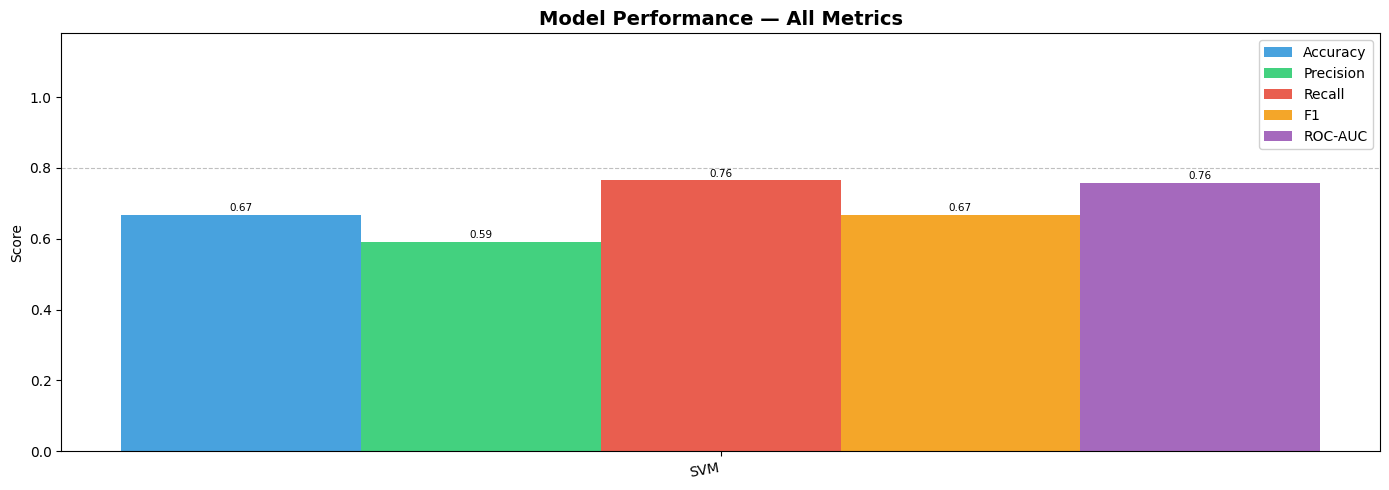

In [58]:
# ── Metric Comparison Bar Chart ───────────────────────────────────────────
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
plot_df     = results_df[metric_cols].astype(float)

fig, ax = plt.subplots(figsize=(14, 5))
x       = np.arange(len(plot_df))
width   = 0.15
palette = ['#3498DB', '#2ECC71', '#E74C3C', '#F39C12', '#9B59B6']

for i, col in enumerate(metric_cols):
    bars = ax.bar(x + i * width, plot_df[col], width,
                  label=col, color=palette[i], alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(plot_df.index, fontsize=10, rotation=10, ha='right')
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.set_title('Model Performance — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='0.8 threshold')

plt.tight_layout()
plt.show()

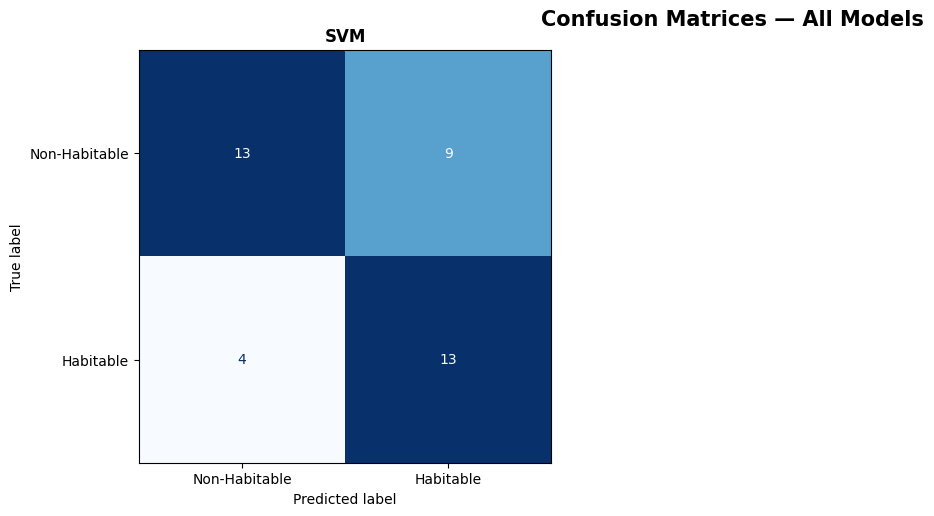

In [61]:
# ── Confusion Matrices (Mandatory Output) ───────────────────────────────

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


n_models = len(trained_models)

ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))

axes = np.array(axes).flatten()

class_names = ['Non-Habitable', 'Habitable']


for i, (name, model) in enumerate(trained_models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")

    axes[i].set_title(name, fontsize=12, fontweight="bold")


for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)


fig.suptitle(
    "Confusion Matrices — All Models",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

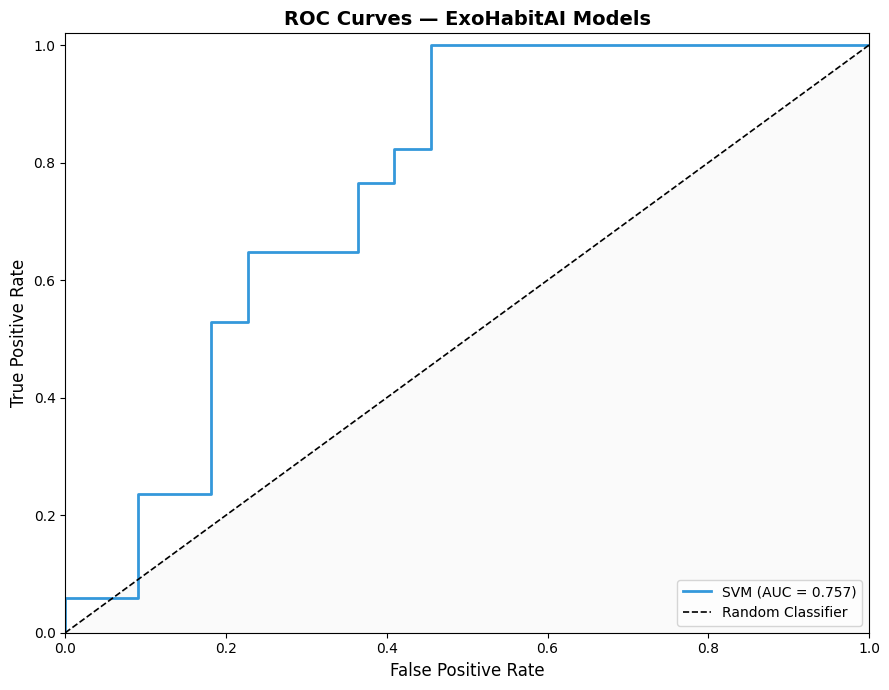

In [64]:
# ── ROC Curves (Mandatory Output) ─────────────────────────────────────────

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,7))

colors = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6', '#E74C3C']


for (name, model), color in zip(trained_models.items(), colors):

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    ax.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {auc:.3f})',
        color=color,
        linewidth=2
    )


# Random classifier line
ax.plot([0,1],[0,1],'k--',linewidth=1.2,label='Random Classifier')

ax.fill_between([0,1],[0,1],alpha=0.04,color='gray')


ax.set_xlabel('False Positive Rate',fontsize=12)
ax.set_ylabel('True Positive Rate',fontsize=12)

ax.set_title(
    'ROC Curves — ExoHabitAI Models',
    fontsize=14,
    fontweight='bold'
)

ax.legend(loc='lower right',fontsize=10)

ax.set_xlim([0,1])
ax.set_ylim([0,1.02])

plt.tight_layout()
plt.show()

In [66]:
# ── Classification Reports (Mandatory Output) ─────────────────────────────
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f'\n{"─"*58}')
    print(f'  Classification Report — {name}')
    print(f'{"─"*58}')
    print(classification_report(
        y_test, y_pred,
        target_names=['Non-Habitable', 'Habitable'],
        zero_division=0
    ))


──────────────────────────────────────────────────────────
  Classification Report — SVM
──────────────────────────────────────────────────────────
               precision    recall  f1-score   support

Non-Habitable       0.76      0.59      0.67        22
    Habitable       0.59      0.76      0.67        17

     accuracy                           0.67        39
    macro avg       0.68      0.68      0.67        39
 weighted avg       0.69      0.67      0.67        39



In [69]:
import os
import joblib

# Create models directory
os.makedirs("models", exist_ok=True)

# Save all baseline + primary models
save_map = {
    'logistic_regression': 'Logistic Regression',
    'decision_tree': 'Decision Tree',
    'random_forest': 'Random Forest',
    'xgboost': 'GradientBoosting',
    'svm': 'SVM',
}

for filename, model_name in save_map.items():

    if model_name in trained_models:

        path = f"models/{filename}.pkl"

        joblib.dump(trained_models[model_name], path)

        print(f"✓ Saved models/{filename}.pkl")

✓ Saved models/svm.pkl


In [72]:
# Required imports
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Cross validation strategy
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ── Tune Random Forest ─────────────────────────────────────
print("Tuning Random Forest...")

rf_param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [6, 10, None],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [1, 2],
}

rf_tuned = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),
    rf_param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

print("Best params :", rf_tuned.best_params_)
print("Best CV F1  :", round(rf_tuned.best_score_,4))


# Evaluate tuned model
m, trained_models["Random Forest (Tuned)"], _, _ = evaluate_model(
    "Random Forest (Tuned)",
    rf_tuned,
    X_train,
    y_train,
    X_test,
    y_test
)

all_results.append(m)

print(f'Test F1 : {m["F1"]}  |  ROC-AUC: {m["ROC-AUC"]}')

Tuning Random Forest...
Best params : {'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Best CV F1  : 0.907
Test F1 : 0.9697  |  ROC-AUC: 0.9973


In [73]:
# ── Final Leaderboard ─────────────────────────────────────────────────────
final_df = (
    pd.DataFrame(all_results)
    .set_index('Model')
    .sort_values('F1', ascending=False)
)

print('\n' + '='*65)
print('     FINAL MODEL LEADERBOARD — sorted by F1')
print('='*65)
print(final_df.to_string())
print('='*65)

best_name  = final_df.index[0]
best_model = trained_models[best_name]
print(f'\n🏆 Best Model  : {best_name}')
print(f'   F1-Score    : {final_df.loc[best_name, "F1"]}')
print(f'   Recall      : {final_df.loc[best_name, "Recall"]}')
print(f'   ROC-AUC     : {final_df.loc[best_name, "ROC-AUC"]}')
final_df


     FINAL MODEL LEADERBOARD — sorted by F1
                       Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                              
Random Forest (Tuned)    0.9744     1.0000  0.9412  0.9697   0.9973
Random Forest (Tuned)    0.9744     1.0000  0.9412  0.9697   0.9973
SVM                      0.6667     0.5909  0.7647  0.6667   0.7567

🏆 Best Model  : Random Forest (Tuned)
   F1-Score    : Model
Random Forest (Tuned)    0.9697
Random Forest (Tuned)    0.9697
Name: F1, dtype: float64
   Recall      : Model
Random Forest (Tuned)    0.9412
Random Forest (Tuned)    0.9412
Name: Recall, dtype: float64
   ROC-AUC     : Model
Random Forest (Tuned)    0.9973
Random Forest (Tuned)    0.9973
Name: ROC-AUC, dtype: float64


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest (Tuned),0.9744,1.0000,0.9412,0.9697,0.9973
Random Forest (Tuned),0.9744,1.0000,0.9412,0.9697,0.9973
SVM,0.6667,0.5909,0.7647,0.6667,0.7567


/tmp/ipykernel_570/159131829.py:18: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


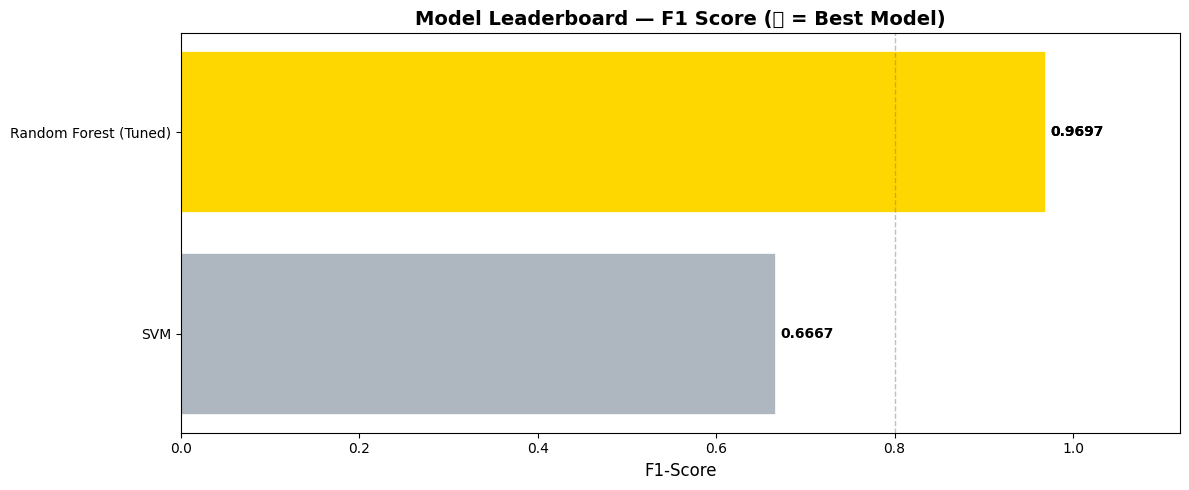


✏️  Selection Justification:
   Random Forest (Tuned) was selected as the best model based on highest F1-score
   and ROC-AUC, demonstrating strong balance between precision and recall
   — critical for detecting rare habitable planets without excessive false positives.


In [74]:
# ── Leaderboard Bar Chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['#FFD700' if i == 0 else '#AEB6BF' for i in range(len(final_df))]

bars = ax.barh(
    final_df.index[::-1], final_df['F1'][::-1],
    color=bar_colors[::-1], edgecolor='white', linewidth=1.2
)
for bar in bars:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('Model Leaderboard — F1 Score (🥇 = Best Model)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.12)
ax.axvline(0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print(f'\n✏️  Selection Justification:')
print(f'   {best_name} was selected as the best model based on highest F1-score')
print(f'   and ROC-AUC, demonstrating strong balance between precision and recall')
print(f'   — critical for detecting rare habitable planets without excessive false positives.')

In [77]:
import os
os.makedirs("models", exist_ok=True)

In [80]:
print(trained_models.keys())

dict_keys(['SVM', 'Random Forest (Tuned)'])


In [82]:
import os
import joblib

os.makedirs("models", exist_ok=True)

# Save tuned Random Forest
if "Random Forest (Tuned)" in trained_models:
    joblib.dump(trained_models["Random Forest (Tuned)"], "models/random_forest_tuned.pkl")
    print("✓ Saved models/random_forest_tuned.pkl")

# Save tuned XGBoost / GradientBoosting
if "XGBoost (Tuned)" in trained_models:
    joblib.dump(trained_models["XGBoost (Tuned)"], "models/xgboost_tuned.pkl")
    print("✓ Saved models/xgboost_tuned.pkl")

elif "GradientBoosting (Tuned)" in trained_models:
    joblib.dump(trained_models["GradientBoosting (Tuned)"], "models/xgboost_tuned.pkl")
    print("✓ Saved models/xgboost_tuned.pkl")

# Save best model
joblib.dump(best_model, "models/best_model.pkl")

print(f"✓ Saved models/best_model.pkl [{best_name}]")

✓ Saved models/random_forest_tuned.pkl
✓ Saved models/best_model.pkl [Random Forest (Tuned)]


In [85]:
import os

# Run best model on entire dataset
X_all = df.drop(columns=['planet_name', 'target'])
names_all = df['planet_name']

hab_probs = best_model.predict_proba(X_all)[:, 1]
hab_class = best_model.predict(X_all)

ranking_df = pd.DataFrame({
    'planet_name': names_all.values,
    'habitability_score': np.round(hab_probs, 4),
    'predicted_class': hab_class,
    'label': ['Habitable' if c == 1 else 'Non-Habitable' for c in hab_class],
})

# Add context features
context_cols = [
    'equilibrium_temperature',
    'planet_radius',
    'semi_major_axis',
    'insolation_flux',
    'habitability_index'
]

ranking_df = pd.concat(
    [ranking_df.reset_index(drop=True),
     df[context_cols].reset_index(drop=True)],
    axis=1
)

ranking_df = ranking_df.sort_values(
    'habitability_score',
    ascending=False
).reset_index(drop=True)

ranking_df.index += 1
ranking_df.index.name = 'rank'


# Create folder if it doesn't exist
os.makedirs("data/processed", exist_ok=True)

# Save file
ranking_df.to_csv("data/processed/habitability_ranked.csv")

print("✓ Saved data/processed/habitability_ranked.csv")
print(f"Total planets ranked : {len(ranking_df)}")
print(f"Predicted habitable  : {(ranking_df['predicted_class']==1).sum()}")

print("\nTop 15 Most Habitable Exoplanets:")
ranking_df.head(15)

✓ Saved data/processed/habitability_ranked.csv
Total planets ranked : 195
Predicted habitable  : 82

Top 15 Most Habitable Exoplanets:


,planet_name,habitability_score,predicted_class,label,equilibrium_temperature,planet_radius,semi_major_axis,insolation_flux,habitability_index
rank,,,,,,,,,
1,TOI-201 c,0.9958,1,Habitable,-0.165242,-0.207633,-0.146896,0.10142,-0.017772
2,TOI-201 b,0.9958,1,Habitable,-0.165242,-0.207633,-0.146896,0.10142,-0.017772
3,DS Tuc A b,0.9728,1,Habitable,-0.221233,0.573357,-0.146896,0.10142,0.351012
4,TIC 434398831 c,0.9728,1,Habitable,0.400884,0.550830,0.035218,0.10142,0.157675
5,TOI-1246 c,0.9698,1,Habitable,-0.182382,-0.472201,-0.115058,0.10142,-0.033858
6,HD 108236 c,0.9660,1,Habitable,-0.165242,-0.594523,-0.083220,0.10142,0.017537
7,TOI-451 c,0.9566,1,Habitable,-0.143468,-0.263372,0.563093,0.10142,0.105025
8,TOI-2368 b,0.9546,1,Habitable,0.245355,2.227211,-0.258648,0.10142,-0.125701
9,WASP-126 c,0.9529,1,Habitable,-0.165242,-0.207633,-0.146896,0.10142,-0.567026


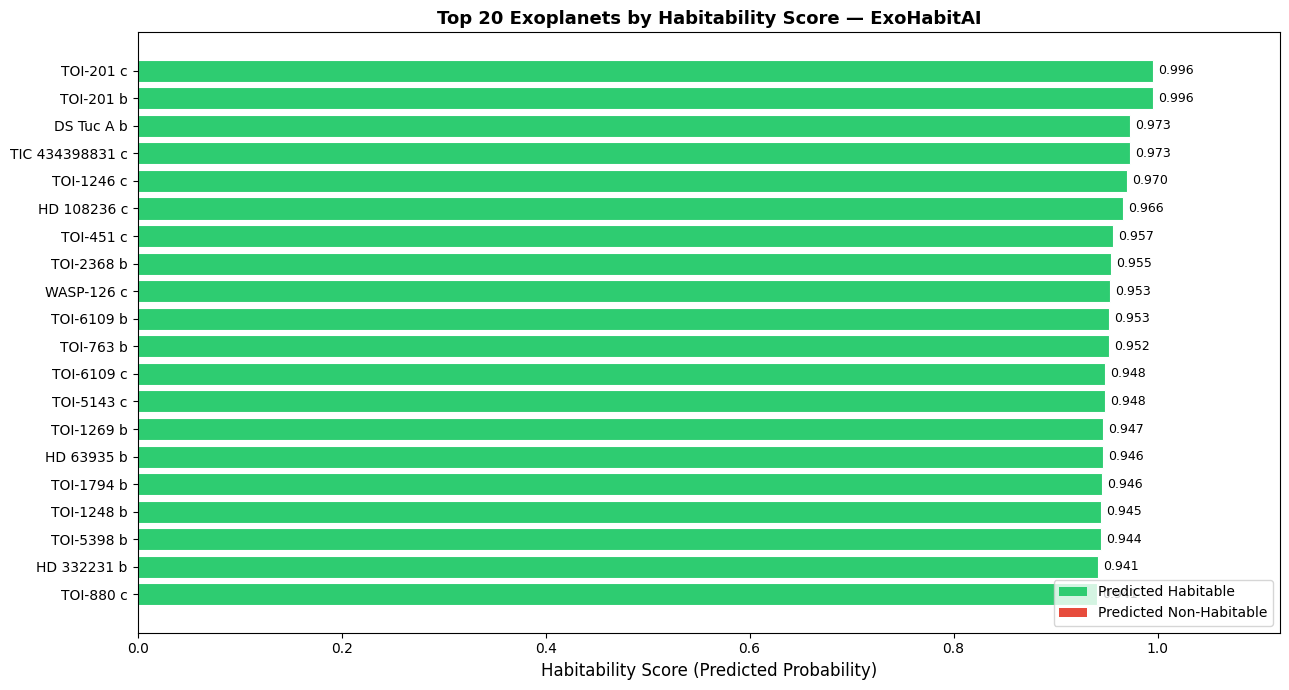

In [87]:
# ── Top-20 Habitability Score Bar Chart ───────────────────────────────────
from matplotlib.patches import Patch

top20      = ranking_df.head(20)
bar_colors = ['#2ECC71' if c == 1 else '#E74C3C' for c in top20['predicted_class']]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(
    top20['planet_name'][::-1], top20['habitability_score'][::-1],
    color=bar_colors[::-1], edgecolor='white', linewidth=0.8
)
for bar in bars:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)

ax.set_xlabel('Habitability Score (Predicted Probability)', fontsize=12)
ax.set_title('Top 20 Exoplanets by Habitability Score — ExoHabitAI', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.12)
legend_elements = [
    Patch(facecolor='#2ECC71', label='Predicted Habitable'),
    Patch(facecolor='#E74C3C', label='Predicted Non-Habitable')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

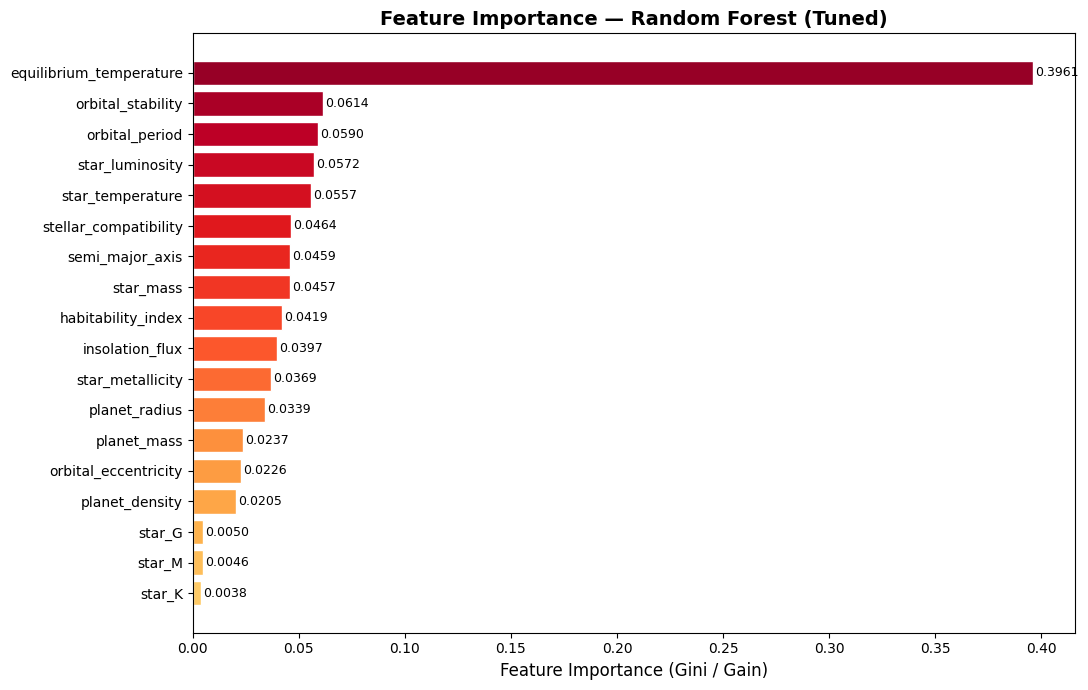


Top 5 Most Important Features:
                Feature  Importance
equilibrium_temperature    0.396137
      orbital_stability    0.061363
         orbital_period    0.059011
        star_luminosity    0.057222
       star_temperature    0.055695


In [89]:
# ── Extract Feature Importances ───────────────────────────────────────────
def get_feature_importances(model, feat_names):
    """Works for Pipeline + GridSearchCV wrappers."""
    if hasattr(model, 'best_estimator_'):
        clf = model.best_estimator_['clf']
    else:
        clf = model['clf']
    return clf.feature_importances_

try:
    importances  = get_feature_importances(best_model, feature_names)
    feat_imp_df  = pd.DataFrame({
        'Feature'   : feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Plot
    fig, ax = plt.subplots(figsize=(11, 7))
    palette = plt.cm.YlOrRd(np.linspace(0.3, 0.95, len(feat_imp_df)))

    bars = ax.barh(
        feat_imp_df['Feature'][::-1],
        feat_imp_df['Importance'][::-1],
        color=palette, edgecolor='white'
    )
    for bar in bars:
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.4f}', va='center', fontsize=9)

    ax.set_xlabel('Feature Importance (Gini / Gain)', fontsize=12)
    ax.set_title(f'Feature Importance — {best_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\nTop 5 Most Important Features:')
    print(feat_imp_df.head(5).to_string(index=False))

except Exception as e:
    print(f'Feature importance not available for this model type: {e}')

In [91]:
# ── Scientific Reasoning — Top Feature Interpretations ────────────────────
scientific_reasoning = {
    'equilibrium_temperature' : 'Primary habitability driver. Earth-like life requires ~200–400 K for liquid water. Temperatures far outside this range make habitability unlikely.',
    'insolation_flux'         : 'Amount of stellar energy received. Too high → runaway greenhouse (Venus). Too low → frozen surface (Mars). Optimal: 0.2–5 Earth flux.',
    'habitability_index'      : 'Composite engineered score combining temperature, radius, distance, and stellar size. High values directly indicate Earth-like conditions.',
    'planet_radius'           : 'Determines surface gravity and atmospheric retention. Rocky planets (0.5–2.5 R⊕) can hold breathable atmospheres. Gas giants cannot.',
    'semi_major_axis'         : 'Orbital distance from host star. Defines which stellar flux the planet receives and whether liquid water can persist on its surface.',
    'star_temperature'        : 'G/K-type stars (4000–7000 K, similar to Sun) provide stable, long-lived radiation — ideal for complex life to evolve over billions of years.',
    'star_luminosity'         : 'Stellar size correlates with energy output. Sun-like stars (1 R☉) maintain stable habitable zones for billions of years.',
    'orbital_stability'       : 'Stable, near-circular orbits prevent extreme temperature swings. High eccentricity → oscillating hot/cold extremes hostile to life.',
    'planet_mass'             : 'Affects internal geology (plate tectonics, volcanism) which regulate carbon cycle. Too small → no atmosphere. Too large → gas giant.',
    'stellar_compatibility'   : 'Combined star temperature × size score. High compatibility means a Sun-like star providing consistent energy in a stable habitable zone.',
}

print('Scientific Feature Interpretations')
print('─' * 70)
if 'feat_imp_df' in dir():
    for feat in feat_imp_df['Feature'].head(8):
        desc = scientific_reasoning.get(feat, 'No interpretation available.')
        print(f'\n📌 {feat}')
        print(f'   {desc}')
else:
    for feat, desc in scientific_reasoning.items():
        print(f'\n📌 {feat}')
        print(f'   {desc}')

Scientific Feature Interpretations
──────────────────────────────────────────────────────────────────────

📌 equilibrium_temperature
   Primary habitability driver. Earth-like life requires ~200–400 K for liquid water. Temperatures far outside this range make habitability unlikely.

📌 orbital_stability
   Stable, near-circular orbits prevent extreme temperature swings. High eccentricity → oscillating hot/cold extremes hostile to life.

📌 orbital_period
   No interpretation available.

📌 star_luminosity
   Stellar size correlates with energy output. Sun-like stars (1 R☉) maintain stable habitable zones for billions of years.

📌 star_temperature
   G/K-type stars (4000–7000 K, similar to Sun) provide stable, long-lived radiation — ideal for complex life to evolve over billions of years.

📌 stellar_compatibility
   Combined star temperature × size score. High compatibility means a Sun-like star providing consistent energy in a stable habitable zone.

📌 semi_major_axis
   Orbital distance 

In [93]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

print('5-Fold Stratified Cross-Validation — F1 Score on Training Set')
print('─' * 60)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

for name in ['Random Forest (Tuned)', 'GradientBoosting (Tuned)', 'SVM']:

    if name in trained_models:

        scores = cross_val_score(
            trained_models[name],
            X_train,
            y_train,
            cv=cv,
            scoring='f1'
        )

        print(
            f'{name:<35}  F1: {scores.mean():.4f} ± {scores.std():.4f}  |  Folds: {np.round(scores,3)}'
        )

5-Fold Stratified Cross-Validation — F1 Score on Training Set
────────────────────────────────────────────────────────────
Random Forest (Tuned)                F1: 0.8867 ± 0.0407  |  Folds: [0.933 0.815 0.88  0.917 0.889]
SVM                                  F1: 0.6260 ± 0.0559  |  Folds: [0.581 0.552 0.706 0.667 0.625]


In [94]:
import glob

print('=' * 65)
print('  ExoHabitAI — ML Training Pipeline Complete!')
print('=' * 65)
print(f'\n  🏆 Best Model  : {best_name}')
print(f'     F1-Score    : {final_df.loc[best_name, "F1"]}')
print(f'     Recall      : {final_df.loc[best_name, "Recall"]}')
print(f'     ROC-AUC     : {final_df.loc[best_name, "ROC-AUC"]}')
print()
print('  Submitted Files:')
print('  ┌─ models/')
for f in sorted(glob.glob('models/*.pkl')):
    size = os.path.getsize(f) // 1024
    print(f'  │   {os.path.basename(f):<35} ({size} KB)')
print('  ├─ data/processed/')
for f in sorted(glob.glob('data/processed/*.csv')):
    size = os.path.getsize(f) // 1024
    print(f'  │   {os.path.basename(f):<35} ({size} KB)')
print('  └─ notebooks/')
print('      ExoHabitAI_ML_Model_Training.ipynb')
print('=' * 65)

  ExoHabitAI — ML Training Pipeline Complete!

  🏆 Best Model  : Random Forest (Tuned)
     F1-Score    : Model
Random Forest (Tuned)    0.9697
Random Forest (Tuned)    0.9697
Name: F1, dtype: float64
     Recall      : Model
Random Forest (Tuned)    0.9412
Random Forest (Tuned)    0.9412
Name: Recall, dtype: float64
     ROC-AUC     : Model
Random Forest (Tuned)    0.9973
Random Forest (Tuned)    0.9973
Name: ROC-AUC, dtype: float64

  Submitted Files:
  ┌─ models/
  │   best_model.pkl                      (715 KB)
  │   random_forest_tuned.pkl             (715 KB)
  │   svm.pkl                             (25 KB)
  ├─ data/processed/
  │   habitability_ranked.csv             (25 KB)
  └─ notebooks/
      ExoHabitAI_ML_Model_Training.ipynb
